# Load Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
meta = pd.read_csv("symbols_valid_meta.csv")
meta.head()

selected_stocks = ['AAPL', 'MSFT', 'TSLA']
meta_filtered = meta[meta['Symbol'].isin(selected_stocks)]
meta_filtered

stock_list = ['AAPL', 'MSFT', 'TSLA']
all_stocks = []
for stock in stock_list:
    df = pd.read_csv(f"stocks/{stock}.csv")
    df['Symbol'] = stock
    all_stocks.append(df)

stocks_df = pd.concat(all_stocks, ignore_index=True)
stocks_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,AAPL
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,AAPL
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,AAPL
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,AAPL
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,AAPL


In [3]:
stocks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20950 entries, 0 to 20949
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       20950 non-null  object 
 1   Open       20950 non-null  float64
 2   High       20950 non-null  float64
 3   Low        20950 non-null  float64
 4   Close      20950 non-null  float64
 5   Adj Close  20950 non-null  float64
 6   Volume     20950 non-null  int64  
 7   Symbol     20950 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.3+ MB


In [6]:
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])
stocks_df.sort_values(['Symbol','Date'], inplace=True)
stocks_df.reset_index(drop=True, inplace=True)
stocks_df.head()

# stocks_df.dtypes

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,AAPL
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,AAPL
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,AAPL
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,AAPL
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,AAPL


In [11]:
print("Minimum Dates:")
print(stocks_df.groupby('Symbol')['Date'].min())

print("\nMaximum Dates:")
print(stocks_df.groupby('Symbol')['Date'].max())

Minimum Dates:
Symbol
AAPL   1980-12-12
MSFT   1986-03-13
TSLA   2010-06-29
Name: Date, dtype: datetime64[ns]

Maximum Dates:
Symbol
AAPL   2020-04-01
MSFT   2020-04-01
TSLA   2020-04-01
Name: Date, dtype: datetime64[ns]


# Data Cleaning

In [13]:
stocks_df.isnull().sum()
stocks_df.fillna(method='ffill', inplace=True)
stocks_df.duplicated().sum()
stocks_df.drop_duplicates(inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_12672\3797867269.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stocks_df.fillna(method='ffill', inplace=True)


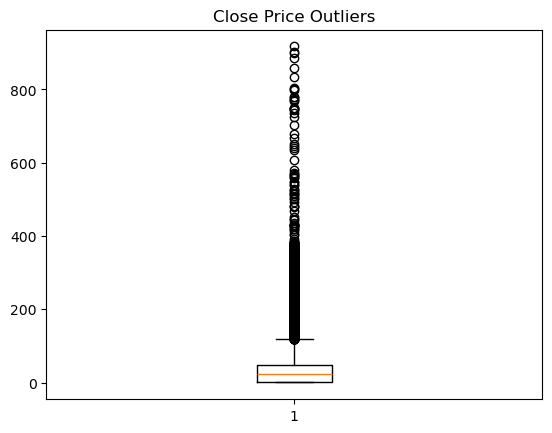

In [17]:
import matplotlib.pyplot as plt

plt.boxplot(stocks_df['Close'])
plt.title("Close Price Outliers")
plt.show()
# To see real market behavior.

stocks_df.sort_values(['Symbol','Date'], inplace=True)
stocks_df.reset_index(drop=True, inplace=True)
stocks_df

In [20]:
df.isnull().sum()
stocks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20950 entries, 0 to 20949
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       20950 non-null  datetime64[ns]
 1   Open       20950 non-null  float64       
 2   High       20950 non-null  float64       
 3   Low        20950 non-null  float64       
 4   Close      20950 non-null  float64       
 5   Adj Close  20950 non-null  float64       
 6   Volume     20950 non-null  int64         
 7   Symbol     20950 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.3+ MB


# EDA

In [21]:
stocks_df.groupby('Symbol')['Close'].describe()

,count,mean,std,min,25%,50%,75%,max
Symbol,,,,,,,,
AAPL,9909.0,32.618030,58.471899,0.196429,1.071429,1.732143,35.761429,327.200012
MSFT,8584.0,29.161905,30.694762,0.090278,3.492188,26.250000,34.542500,188.699997
TSLA,2457.0,194.344526,134.449616,15.800000,34.570000,215.210007,273.600006,917.419983


In [23]:
stocks_df['Daily_Return'] = stocks_df.groupby('Symbol')['Close'].pct_change()

stocks_df.groupby('Symbol')['Daily_Return'].std()



# Volatility Analysis:

# • Tesla exhibits the highest daily return volatility.
# • Microsoft shows the most stable price behavior.
# • Apple falls between Tesla and Microsoft in terms of risk.
# • Higher volatility implies higher risk and potential reward.

Symbol
AAPL    0.028738
MSFT    0.021556
TSLA    0.034177
Name: Daily_Return, dtype: float64

In [24]:
pivot_close = stocks_df.pivot(index='Date', columns='Symbol', values='Close')
pivot_close.corr()

Symbol,AAPL,MSFT,TSLA
Symbol,,,
AAPL,1.000000,0.894670,0.843626
MSFT,0.894670,1.000000,0.788965
TSLA,0.843626,0.788965,1.000000


In [25]:
pivot_return = stocks_df.pivot(index='Date', columns='Symbol', values='Daily_Return')
pivot_return.corr()

# Return Correlation Analysis:

# • Return correlations are significantly lower than price correlations.
# • Apple and Microsoft show moderate positive correlation.
# • Tesla exhibits lower correlation with both Apple and Microsoft.
# • Diversification benefits exist when combining these stocks in a portfolio.

Symbol,AAPL,MSFT,TSLA
Symbol,,,
AAPL,1.000000,0.41198,0.279438
MSFT,0.411980,1.00000,0.295450
TSLA,0.279438,0.29545,1.000000


# Feature Engineering (Model Preparation)

In [26]:
stocks_df['MA10'] = stocks_df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(10).mean())
stocks_df['MA50'] = stocks_df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(50).mean())

stocks_df[['Symbol','Date','Close','MA10','MA50']].head(15)

,Symbol,Date,Close,MA10,MA50
0,AAPL,1980-12-12,0.513393,NaN,NaN
1,AAPL,1980-12-15,0.486607,NaN,NaN
2,AAPL,1980-12-16,0.450893,NaN,NaN
3,AAPL,1980-12-17,0.462054,NaN,NaN
4,AAPL,1980-12-18,0.475446,NaN,NaN
5,AAPL,1980-12-19,0.504464,NaN,NaN
6,AAPL,1980-12-22,0.529018,NaN,NaN
7,AAPL,1980-12-23,0.551339,NaN,NaN
8,AAPL,1980-12-24,0.580357,NaN,NaN
9,AAPL,1980-12-26,0.633929,0.518750,NaN


# RSI (Relative Strength Index)

In [28]:
def calculate_rsi(series):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

stocks_df['RSI'] = stocks_df.groupby('Symbol')['Close'].transform(calculate_rsi)
stocks_df[['Symbol','Date','Close','RSI']].head(20)

,Symbol,Date,Close,RSI
0,AAPL,1980-12-12,0.513393,NaN
1,AAPL,1980-12-15,0.486607,NaN
2,AAPL,1980-12-16,0.450893,NaN
3,AAPL,1980-12-17,0.462054,NaN
4,AAPL,1980-12-18,0.475446,NaN
5,AAPL,1980-12-19,0.504464,NaN
6,AAPL,1980-12-22,0.529018,NaN
7,AAPL,1980-12-23,0.551339,NaN
8,AAPL,1980-12-24,0.580357,NaN
9,AAPL,1980-12-26,0.633929,NaN


In [30]:
stocks_df['Target'] = stocks_df.groupby('Symbol')['Close'].shift(-1) > stocks_df['Close']
stocks_df['Target'] = stocks_df['Target'].astype(int)
stocks_df[['Symbol','Date','Close','Target']].head(15)

# 1 → If next day close price is higher
# 0 → If next day close price is lower

,Symbol,Date,Close,Target
0,AAPL,1980-12-12,0.513393,0
1,AAPL,1980-12-15,0.486607,0
2,AAPL,1980-12-16,0.450893,1
3,AAPL,1980-12-17,0.462054,1
4,AAPL,1980-12-18,0.475446,1
5,AAPL,1980-12-19,0.504464,1
6,AAPL,1980-12-22,0.529018,1
7,AAPL,1980-12-23,0.551339,1
8,AAPL,1980-12-24,0.580357,1
9,AAPL,1980-12-26,0.633929,1


In [31]:
stocks_df.dropna(inplace=True)
stocks_df.reset_index(drop=True, inplace=True)

stocks_df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Symbol          0
Daily_Return    0
MA10            0
MA50            0
RSI             0
Target          0
dtype: int64

# Model Building (Classification)

Model Evaluation Metrics
------------------------
Accuracy : 0.5028
Precision: 0.5179
Recall   : 0.6145
F1-Score : 0.5621


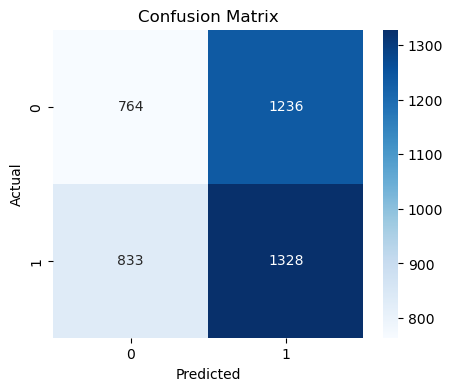

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy = accuracy_score(y_test, pred)

# Precision, Recall, F1
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("Model Evaluation Metrics")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Visualization

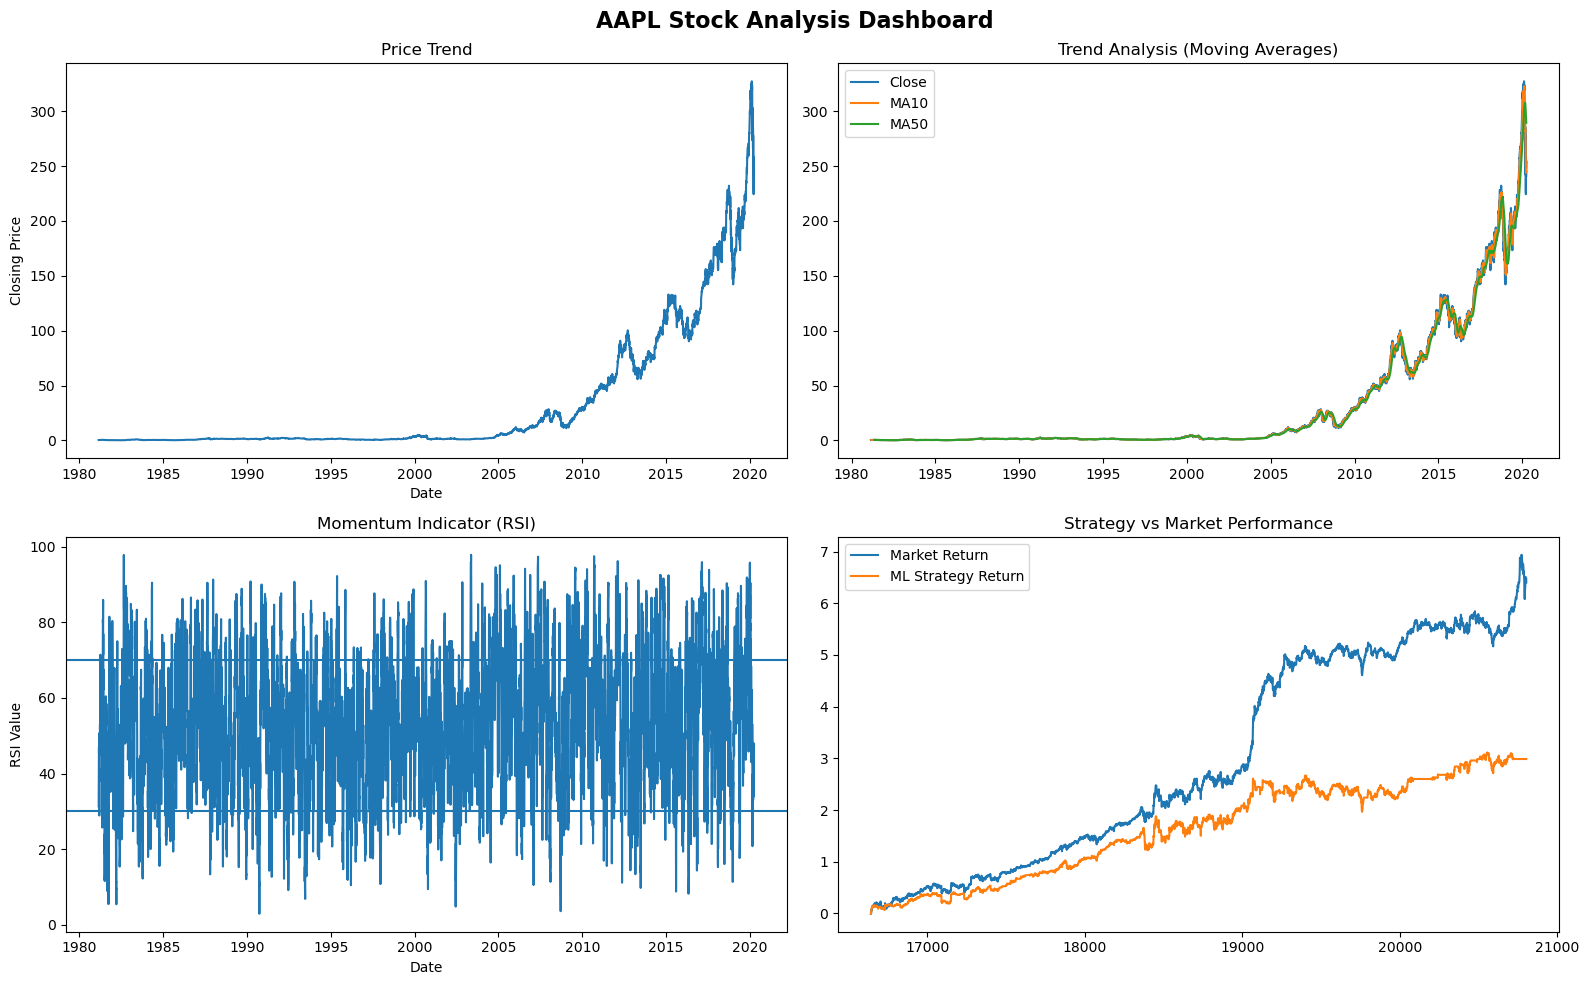

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure Date format
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])
stocks_df = stocks_df.sort_values(['Symbol','Date'])

# Select stock
stock_symbol = 'AAPL'   # Change if needed
stock_data = stocks_df[stocks_df['Symbol'] == stock_symbol]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle(f"{stock_symbol} Stock Analysis Dashboard", fontsize=16, fontweight='bold')

# 1️⃣ Closing Price
axes[0,0].plot(stock_data['Date'], stock_data['Close'])
axes[0,0].set_title("Price Trend")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Closing Price")

# 2️⃣ Moving Averages
axes[0,1].plot(stock_data['Date'], stock_data['Close'], label='Close')
axes[0,1].plot(stock_data['Date'], stock_data['MA10'], label='MA10')
axes[0,1].plot(stock_data['Date'], stock_data['MA50'], label='MA50')
axes[0,1].set_title("Trend Analysis (Moving Averages)")
axes[0,1].legend()

# 3️⃣ RSI
axes[1,0].plot(stock_data['Date'], stock_data['RSI'])
axes[1,0].axhline(70)
axes[1,0].axhline(30)
axes[1,0].set_title("Momentum Indicator (RSI)")
axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("RSI Value")

# 4️⃣ Strategy vs Market
axes[1,1].plot(test_df['Market_Cumulative'], label="Market Return")
axes[1,1].plot(test_df['Strategy_Cumulative'], label="ML Strategy Return")
axes[1,1].set_title("Strategy vs Market Performance")
axes[1,1].legend()

plt.tight_layout()
plt.show()

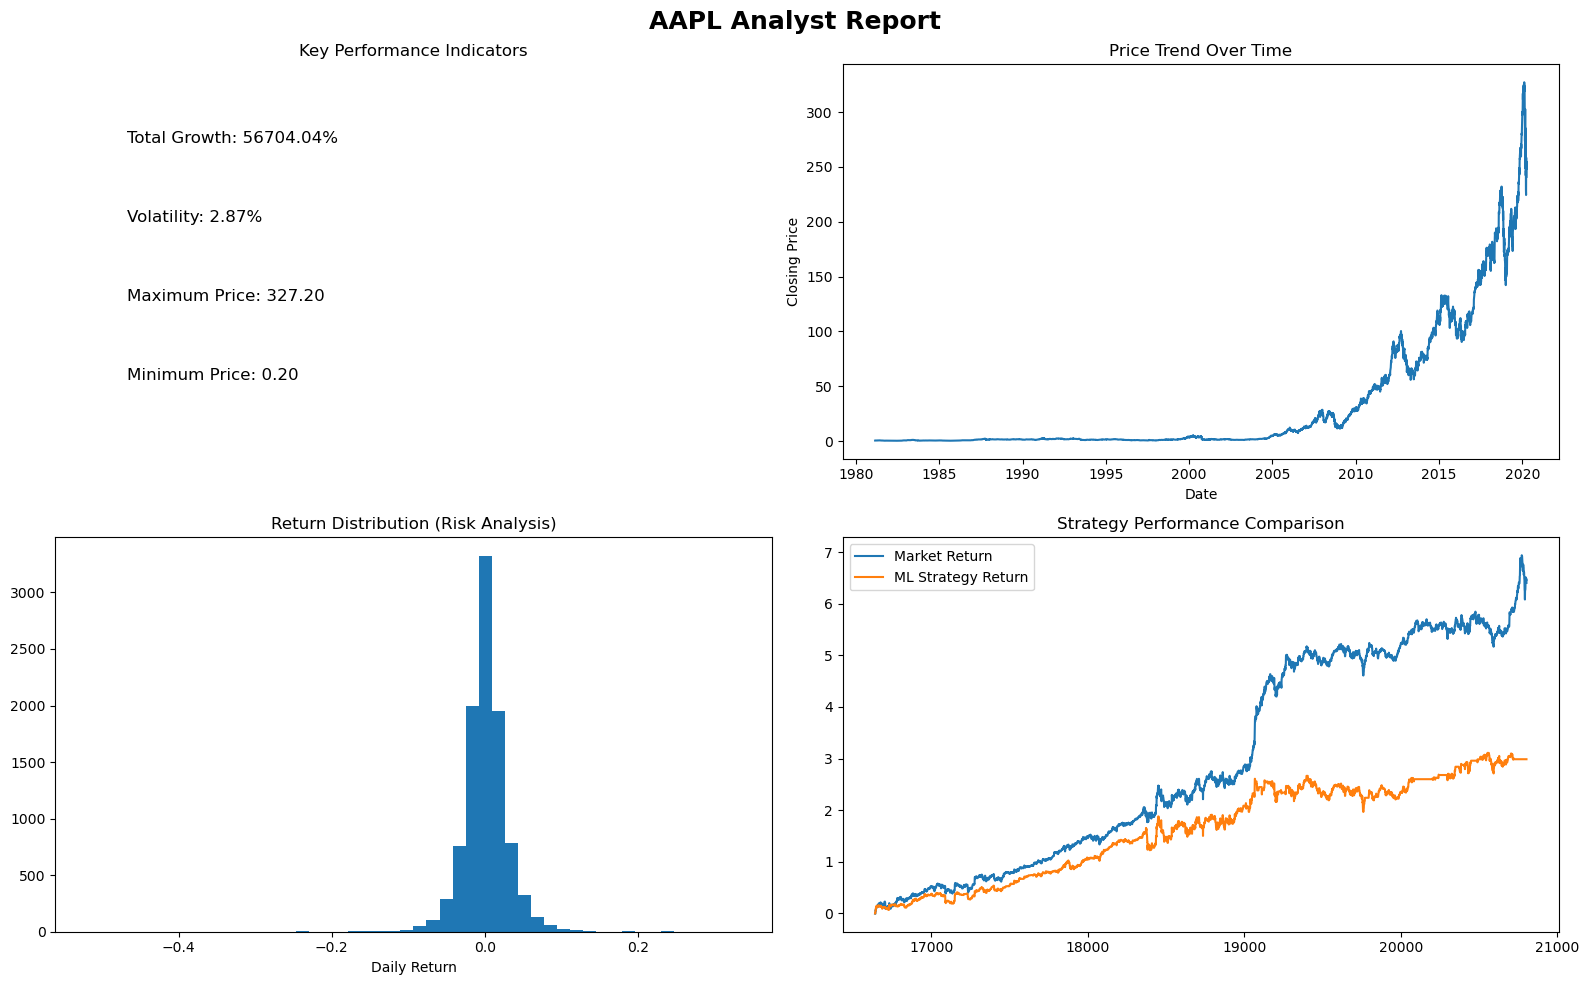

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure date format
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])
stocks_df = stocks_df.sort_values(['Symbol','Date'])

stock_symbol = 'AAPL'  # Change if needed
stock_data = stocks_df[stocks_df['Symbol'] == stock_symbol].copy()

# ---- KPI Calculations ----
total_return = (stock_data['Close'].iloc[-1] / stock_data['Close'].iloc[0] - 1) * 100
volatility = stock_data['Daily_Return'].std() * 100
max_price = stock_data['Close'].max()
min_price = stock_data['Close'].min()

# ---- Create Report Layout ----
fig = plt.figure(figsize=(16,10))
fig.suptitle(f"{stock_symbol} Analyst Report", fontsize=18, fontweight='bold')

# 1️⃣ KPI TEXT PANEL
plt.subplot(2,2,1)
plt.axis('off')
plt.text(0.1, 0.8, f"Total Growth: {total_return:.2f}%", fontsize=12)
plt.text(0.1, 0.6, f"Volatility: {volatility:.2f}%", fontsize=12)
plt.text(0.1, 0.4, f"Maximum Price: {max_price:.2f}", fontsize=12)
plt.text(0.1, 0.2, f"Minimum Price: {min_price:.2f}", fontsize=12)
plt.title("Key Performance Indicators")

# 2️⃣ Price Trend
plt.subplot(2,2,2)
plt.plot(stock_data['Date'], stock_data['Close'])
plt.title("Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# 3️⃣ Risk (Volatility Visualization)
plt.subplot(2,2,3)
plt.hist(stock_data['Daily_Return'].dropna(), bins=50)
plt.title("Return Distribution (Risk Analysis)")
plt.xlabel("Daily Return")

# 4️⃣ Strategy vs Market
plt.subplot(2,2,4)
plt.plot(test_df['Market_Cumulative'], label="Market Return")
plt.plot(test_df['Strategy_Cumulative'], label="ML Strategy Return")
plt.title("Strategy Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

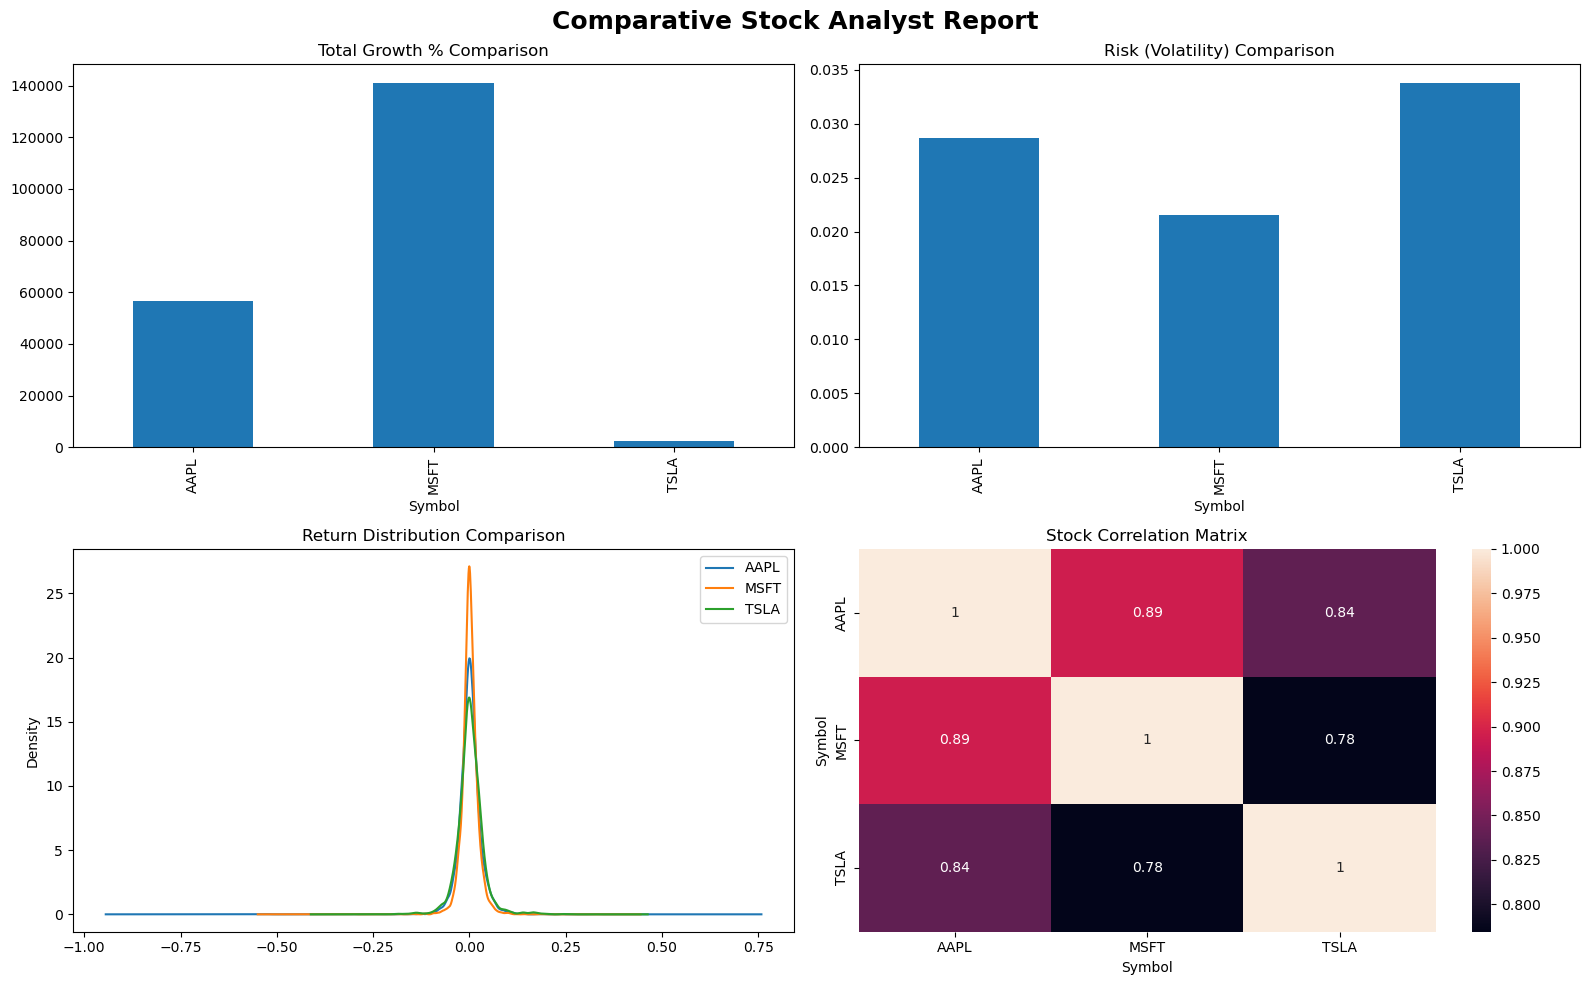

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])
stocks_df = stocks_df.sort_values(['Symbol','Date'])

# KPI Aggregation
summary = stocks_df.groupby('Symbol').agg(
    Growth_Percent=('Close', lambda x: (x.iloc[-1]/x.iloc[0]-1)*100),
    Volatility=('Daily_Return','std')
)

# Pivot for correlation
pivot = stocks_df.pivot_table(values='Close', index='Date', columns='Symbol')
corr = pivot.corr()

# ---- Dashboard ----
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Comparative Stock Analyst Report", fontsize=18, fontweight='bold')

# 1️⃣ Growth Comparison
summary['Growth_Percent'].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Total Growth % Comparison")

# 2️⃣ Volatility Comparison
summary['Volatility'].plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Risk (Volatility) Comparison")

# 3️⃣ Return Distribution
for symbol in stocks_df['Symbol'].unique():
    stocks_df[stocks_df['Symbol']==symbol]['Daily_Return'].plot(
        kind='kde', ax=axes[1,0], label=symbol)
axes[1,0].set_title("Return Distribution Comparison")
axes[1,0].legend()

# 4️⃣ Correlation Matrix
sns.heatmap(corr, annot=True, ax=axes[1,1])
axes[1,1].set_title("Stock Correlation Matrix")

plt.tight_layout()
plt.show()